In [ ]:
#read in adata objects
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

In [ ]:
#read in adata objects
adatas = ad.read_h5ad('../data/background_removed/salivary_glands_annotated_5_1_26.h5ad')

### subsets

In [34]:
rpg_only = adatas[adatas.obs['organ'] == 'RPG', :].copy()
parotid_only = adatas[adatas.obs['organ'] == 'parotid', :].copy()
smg_only = adatas[adatas.obs['organ'] == 'SMG', :].copy()
slg_only = adatas[adatas.obs['organ'] == 'SLG', :].copy()
rpg_only

AnnData object with n_obs × n_vars = 14963 × 931
    obs: 'name', 'spotId', 'x', 'y', 'leiden', 'organ', 'leiden_backup'
    uns: 'leiden', 'log1p', 'name', 'neighbors', 'pca', 'umap', 'organ_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

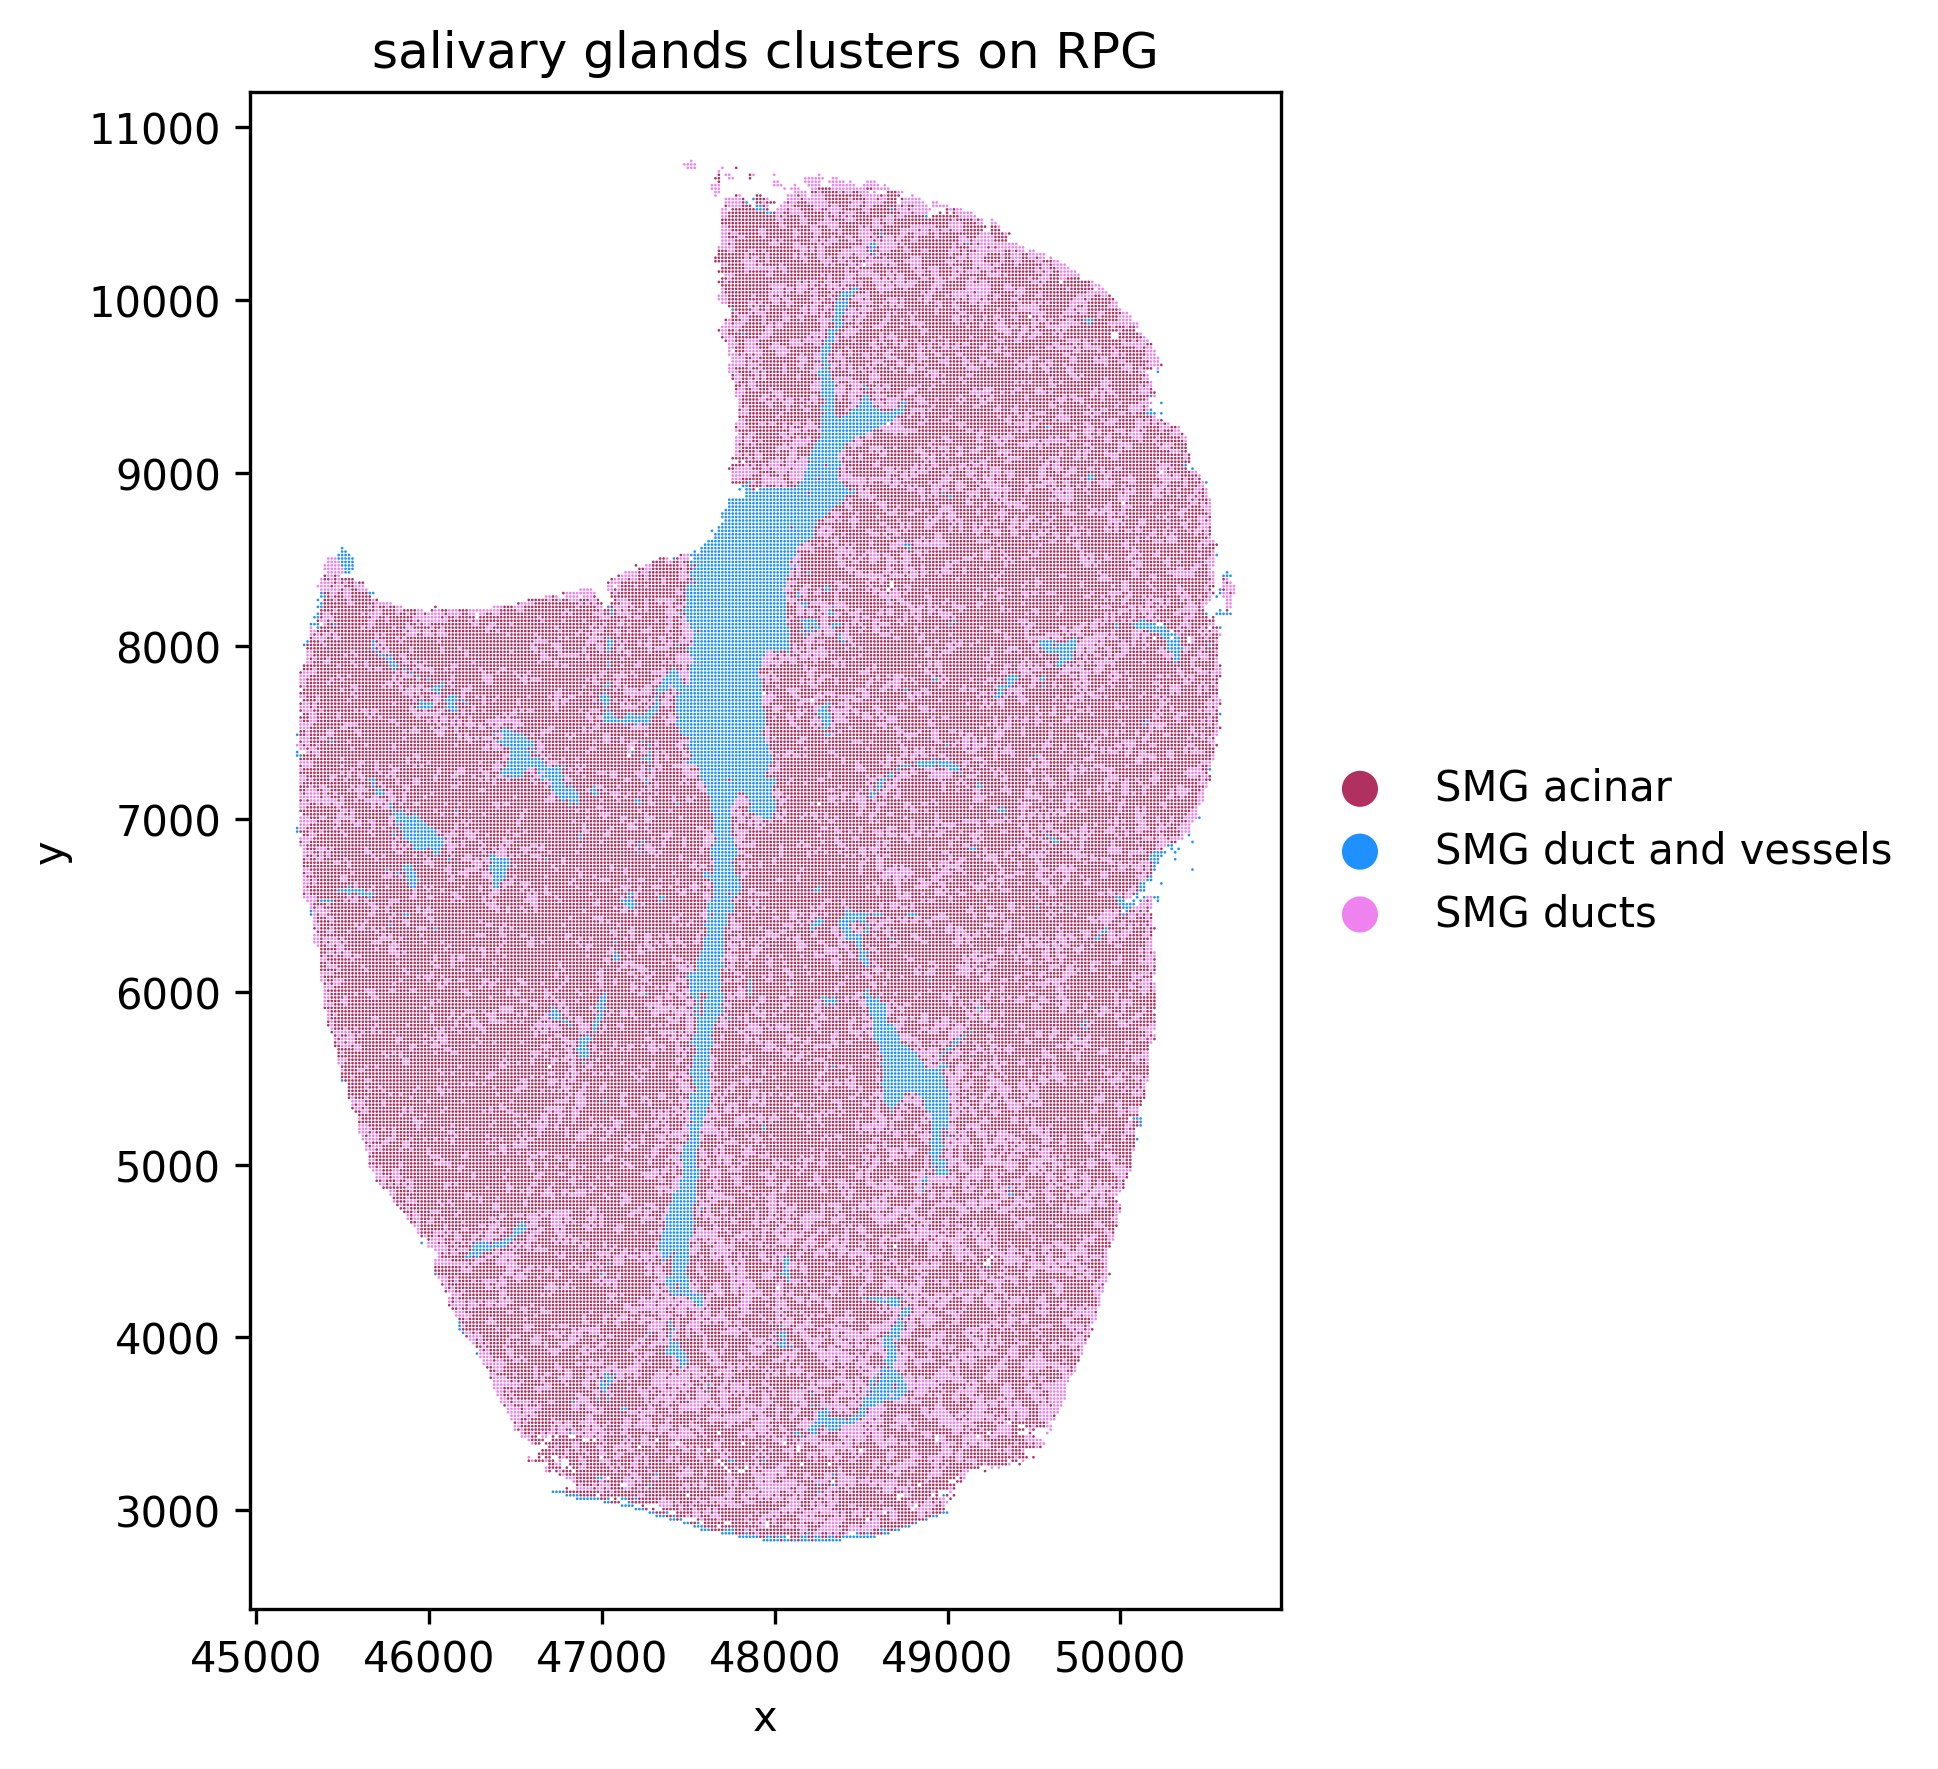

In [31]:

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
sc.pl.scatter(smg_only, x='x', y='y', color='leiden', show=False, title='salivary glands clusters on RPG', ax=ax)
ax.set_aspect('equal')
plt.tight_layout()

#plt.savefig(f'plots/{name}_organs_scatter.pdf')
#plt.savefig(f'plots/{name}_organs_scatter.png', dpi=500)

plt.show()

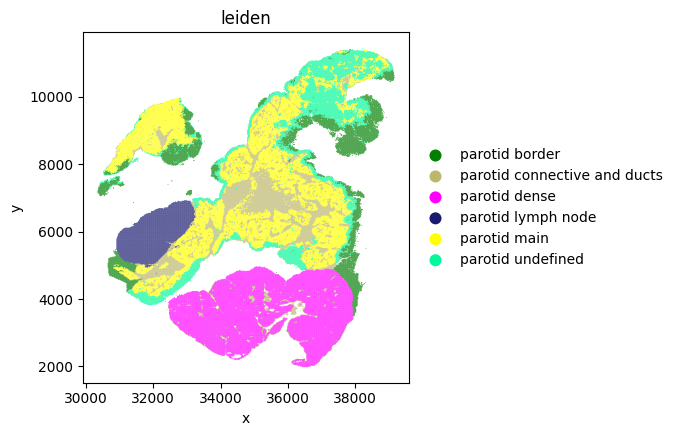

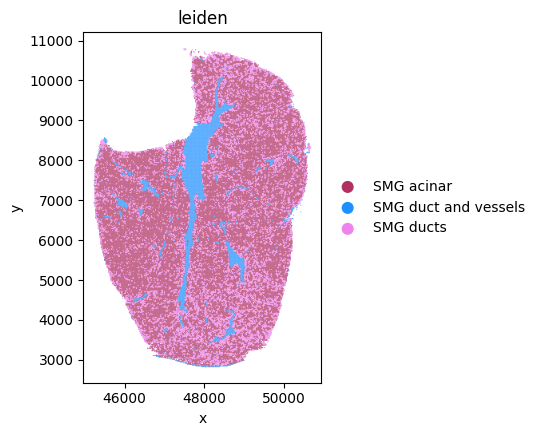

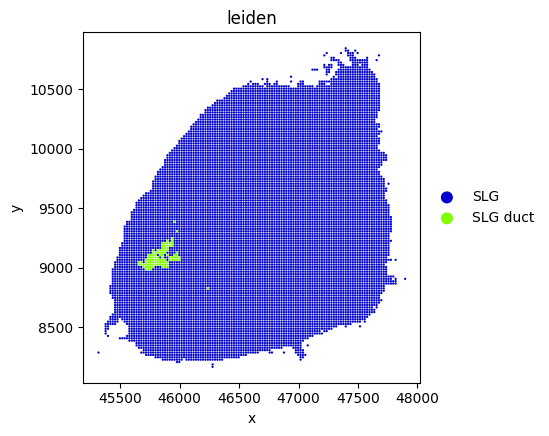

In [32]:
sc.pl.scatter(parotid_only, x='x', y='y', color='leiden', show=False)
plt.gca().set_aspect('equal', adjustable='box')
sc.pl.scatter(smg_only, x='x', y='y', color='leiden', show=False)
plt.gca().set_aspect('equal', adjustable='box')
sc.pl.scatter(slg_only, x='x', y='y', color='leiden', show=False)
plt.gca().set_aspect('equal', adjustable='box')

### merging and renaming clusters

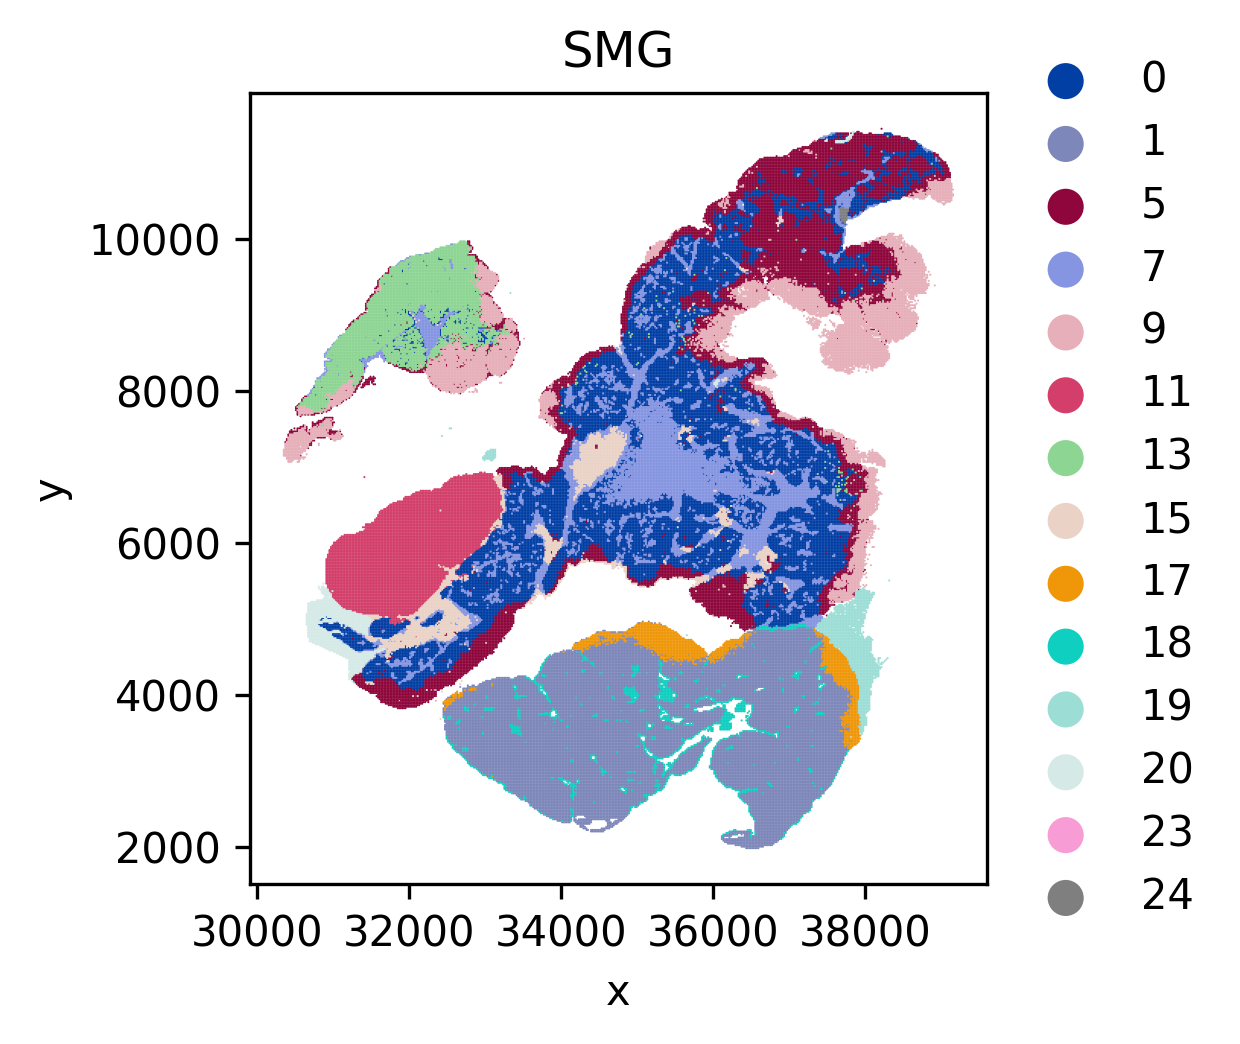

In [46]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
sc.pl.scatter(parotid_only, x='x', y='y', color='leiden', show=False, title='SMG', ax=ax, size = 1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

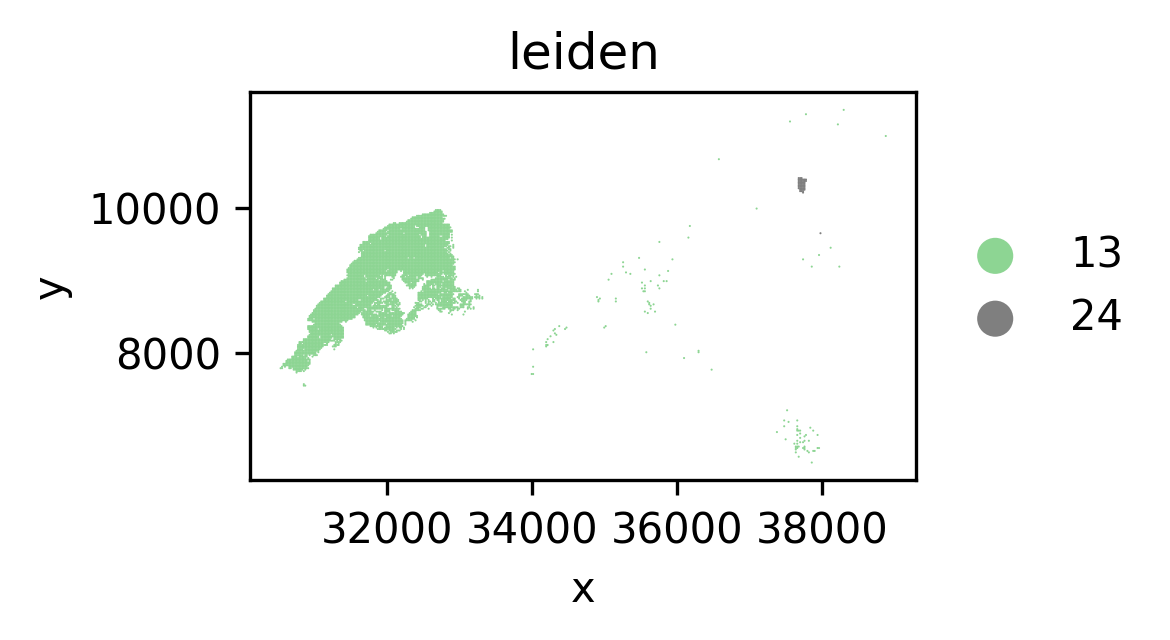

In [55]:
#plot clusters on x and y coordinates
mask = (
    (adatas.obs['leiden'].isin(['24','13']))
)
# subset the AnnData and plot the filtered spots
subset = adatas[mask]
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
sc.pl.scatter(subset, x='x', y='y', color='leiden', show=False, size=1, ax=ax)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
### merge and clusters to be more meaningfull
#create new column leiden_backup to preserve original leiden clusters
#adatas.obs['leiden'] = adatas.obs['leiden_backup'].copy()
#adatas.obs['leiden_backup'] = adatas.obs['leiden'].copy()

# change organ baser on cluster assignment
for cluster, organ in [('2', 'SMG'), ('3', 'SMG'), ('4', 'SMG'), ('6', 'SMG'), ('12', 'SMG'), ('8', 'SLG'), ('23', 'SLG')]:
    adatas.obs.loc[adatas.obs['leiden'] == cluster, 'organ'] = organ

# remove spot with Organ == 'SLG' and x < 35000
adatas = adatas[~((adatas.obs['organ'] == 'SLG') & (adatas.obs['x'] < 35000)), :].copy()
# merge and rename clusters to be descriptive

adatas.obs['leiden'] = adatas.obs['leiden'].astype(str)
adatas.obs.loc[adatas.obs['leiden'].isin(['10']), 'leiden'] = 'RPG secretory'
adatas.obs.loc[adatas.obs['leiden'].isin(['14']), 'leiden'] = 'RPG epithelial'
adatas.obs.loc[adatas.obs['leiden'].isin(['21']), 'leiden'] = 'RPG nerve'
adatas.obs.loc[adatas.obs['leiden'].isin(['16']), 'leiden'] = 'RPG border'
adatas.obs.loc[adatas.obs['leiden'].isin(['22']), 'leiden'] = 'RPG muscle'
adatas.obs.loc[adatas.obs['leiden'].isin(['23']), 'leiden'] = 'SLG duct'
adatas.obs.loc[adatas.obs['leiden'].isin(['8']), 'leiden'] = 'SLG'
adatas.obs.loc[adatas.obs['leiden'].isin(['12']), 'leiden'] = 'SMG duct and vessels'
adatas.obs.loc[adatas.obs['leiden'].isin(['2']), 'leiden'] = 'SMG acinar'
adatas.obs.loc[adatas.obs['leiden'].isin(['3']), 'leiden'] = 'SMG ducts'
adatas.obs.loc[adatas.obs['leiden'].isin(['4']), 'leiden'] = 'SMG acinar'
adatas.obs.loc[adatas.obs['leiden'].isin(['6']), 'leiden'] = 'SMG acinar'


adatas.obs.loc[adatas.obs['leiden'].isin(['9']), 'leiden'] = 'parotid border'
adatas.obs.loc[adatas.obs['leiden'].isin(['19']), 'leiden'] = 'parotid border'
adatas.obs.loc[adatas.obs['leiden'].isin(['1']), 'leiden'] = 'parotid dense'
adatas.obs.loc[adatas.obs['leiden'].isin(['11']), 'leiden'] = 'parotid lymph node'
adatas.obs.loc[adatas.obs['leiden'].isin(['15']), 'leiden'] = 'parotid connective and ducts'
adatas.obs.loc[adatas.obs['leiden'].isin(['20']), 'leiden'] = 'parotid border'
adatas.obs.loc[adatas.obs['leiden'].isin(['7']), 'leiden'] = 'parotid connective and ducts'
adatas.obs.loc[adatas.obs['leiden'].isin(['18']), 'leiden'] = 'parotid dense'
adatas.obs.loc[adatas.obs['leiden'].isin(['13']), 'leiden'] = 'parotid main'
adatas.obs.loc[adatas.obs['leiden'].isin(['0']), 'leiden'] = 'parotid main'
adatas.obs.loc[adatas.obs['leiden'].isin(['5']), 'leiden'] = 'parotid undefined'
adatas.obs.loc[adatas.obs['leiden'].isin(['17']), 'leiden'] = 'parotid dense'
adatas.obs.loc[adatas.obs['leiden'].isin(['24']), 'leiden'] = 'parotid undefined'


adatas.obs['leiden'] = adatas.obs['leiden'].astype('category')
adatas.obs['leiden'].unique()

['SLG', 'SMG ducts', 'SMG acinar', 'SMG duct and vessels', 'SLG duct', ..., 'parotid border', 'parotid connective and ducts', 'parotid main', 'parotid lymph node', 'parotid dense']
Length: 16
Categories (16, object): ['RPG border', 'RPG epithelial', 'RPG muscle', 'RPG nerve', ..., 'parotid dense', 'parotid lymph node', 'parotid main', 'parotid undefined']

### plotting

In [ ]:
# choose colors based on existing palette

# get cluster categories
clusters = adatas.obs['leiden'].cat.categories
# generate distinct colors (e.g., tab20 or any palette you want)
palette = sns.color_palette("tab20", n_colors=len(clusters)).as_hex()
# assign colors to adata
adatas.uns['leiden_colors'] = palette


In [ ]:
default_palette = [
    '#1f77b4',
  '#ff7f0e',
  '#279e68',
  '#d62728',
  '#aa40fc',
  '#8c564b', 
  '#ad494a',
  '#e377c2', 
  '#b5bd61',
      '#17becf',
       '#98df8a',
   '#ff9896',
     '#c5b0d5',
  '#c49c94',
  '#f7b6d2',
  '#dbdb8d',
  ]

clusters = adatas.obs['leiden'].cat.categories
adatas.uns['leiden_colors'] = default_palette[:len(clusters)]

In [22]:
palette = [
    "#191970",  # midnightblue
    "#dc143c",  # NEW: crimson (deep red)
    "#2ca02c",  # green
    "#41B3A3"   # mint teal
]

clusters = adatas.obs['organ'].cat.categories
adatas.uns['organ_colors'] = palette[:len(clusters)]

In [7]:
# Randomly re-order the data for plotting
random_indices = np.random.default_rng(0).permutation(list(range(adatas.shape[0])))

In [ ]:
#plot adatas UMAP and PCA with organ colors, save as PDF
sc.pl.umap(adatas[random_indices, :], color='organ', title='UMAP: salivary glands - organ', size = 3, save="_salivary_glands_organ.pdf")
sc.pl.umap(adatas[random_indices, :], color='leiden', title='UMAP: salivary glands - leiden clusters', size = 3, save="_salivary_glands_leiden.pdf")

#plot PCs
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,2'], size=5, save="_salivary_glands_organ_components_1_2.pdf")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,2'], size=5, save="_salivary_glands_leiden_components_1_2.pdf")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,3'], size=5, save="_salivary_glands_organ_components_1_3.pdf")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,3'], size=5, save="_salivary_glands_leiden_components_1_3.pdf")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['2,3'], size=5, save="_salivary_glands_organ_components_2_3.pdf")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['2,3'], size=5, save="_salivary_glands_leiden_components_2_3.pdf")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['4,5'], size=5, save="_salivary_glands_organ_components_4_5.pdf")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['4,5'], size=5, save="_salivary_glands_leiden_components_4_5.pdf")

In [ ]:
#plot adatas UMAP and PCA with organ colors, save as SVG
sc.pl.umap(adatas[random_indices, :], color='organ', title='UMAP: salivary glands - organ', size = 3, save="_salivary_glands_organ.svg")
sc.pl.umap(adatas[random_indices, :], color='leiden', title='UMAP: salivary glands - leiden clusters', size = 3, save="_salivary_glands_leiden.svg")

#plot PCs
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,2'], size=5, save="_salivary_glands_organ_components_1_2.svg")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,2'], size=5, save="_salivary_glands_leiden_components_1_2.svg")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,3'], size=5, save="_salivary_glands_organ_components_1_3.svg")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,3'], size=5, save="_salivary_glands_leiden_components_1_3.svg")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['2,3'], size=5, save="_salivary_glands_organ_components_2_3.svg")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['2,3'], size=5, save="_salivary_glands_leiden_components_2_3.svg")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['4,5'], size=5, save="_salivary_glands_organ_components_4_5.svg")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['4,5'], size=5, save="_salivary_glands_leiden_components_4_5.svg")

#### cleaned organs subset

In [55]:
#filter out clusters corresponding to border and connective tissue
remove_border = adatas.obs['leiden'].isin(['RPG border', 'parotid border', 'parotid undefined', 'parotid lymph node', 'RPG muscle', 'RPG epithelial'])
adatas_sub = adatas[~remove_border, :].copy()
random_indices_sub = np.random.default_rng(0).permutation(list(range(adatas_sub.shape[0])))

In [ ]:
#plot filtered adatas UMAP and PCA with organ colors, save as pdf
sc.pl.umap(adatas_sub[random_indices_sub, :], color='organ', title='UMAP: salivary glands - organ', size = 3, save="_filtered_salivary_glands_organ.pdf")
sc.pl.umap(adatas_sub[random_indices_sub, :], color='leiden', title='UMAP: salivary glands - leiden clusters', size = 3, save="_filtered_salivary_glands_leiden.pdf")
#plot PCs
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,2'], size=5, save="_filtered_salivary_glands_organ_components_1_2.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,2'], size=5, save="_filtered_salivary_glands_leiden_components_1_2.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,3'], size=5, save="_filtered_salivary_glands_organ_components_1_3.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,3'], size=5, save="_filtered_salivary_glands_leiden_components_1_3.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['2,3'], size=5, save="_filtered_salivary_glands_organ_components_2_3.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['2,3'], size=5, save="_filtered_salivary_glands_leiden_components_2_3.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['4,5'], size=5, save="_filtered_salivary_glands_organ_components_4_5.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['4,5'], size=5, save="_filtered_salivary_glands_leiden_components_4_5.pdf")

In [ ]:

#plot filtered adatas UMAP and PCA with organ colors, save as SVG
sc.pl.umap(adatas_sub[random_indices_sub, :], color='organ', title='UMAP: salivary glands - organ', size = 3, save="_filtered_salivary_glands_organ.svg")
sc.pl.umap(adatas_sub[random_indices_sub, :], color='leiden', title='UMAP: salivary glands - leiden clusters', size = 3, save="_filtered_salivary_glands_leiden.svg")
#plot PCs
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,2'], size=5, save="_filtered_salivary_glands_organ_components_1_2.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,2'], size=5, save="_filtered_salivary_glands_leiden_components_1_2.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['1,3'], size=5, save="_filtered_salivary_glands_organ_components_1_3.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['1,3'], size=5, save="_filtered_salivary_glands_leiden_components_1_3.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['2,3'], size=5, save="_filtered_salivary_glands_organ_components_2_3.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['2,3'], size=5, save="_filtered_salivary_glands_leiden_components_2_3.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: salivary glands - organ', annotate_var_explained=True, components=['4,5'], size=5, save="_filtered_salivary_glands_organ_components_4_5.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: salivary glands - leiden clusters', annotate_var_explained=True, components=['4,5'], size=5, save="_filtered_salivary_glands_leiden_components_4_5.svg")

In [ ]:
#plotting all organs scatter for filtered data
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
sc.pl.scatter(adatas_sub[random_indices_sub, :], x='x', y='y', color='organ', title=f'salivary glands, filtered', show=False, ax=ax,save="_filtered_salivary_glands.svg")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
#plotting all organs scatter with leiden colors, filtered
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
sc.pl.scatter(adatas_sub[random_indices_sub, :], x='x', y='y', color='leiden', show=False, title='filtered salivary glands clusters, 20um spots', ax=ax, save="_filtered_salivary_glands_leiden.svg")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### exploration

In [10]:
# find genes that define the PCs
#sc.pp.pca(adatas[5], n_comps=20, use_highly_variable=True, svd_solver='arpack')
pc_mz = pd.DataFrame(adatas.varm['PCs'], index=adatas.var_names)
for i in range(5):
    print(f"Top ions for PC {i+1}:")
    print(pc_mz[i].sort_values(ascending=False).head(10))

Top ions for PC 1:
Dihydro-O-methylsterigmatocystin, [+4 syn.] (mz339.0894)                0.101809
mz171.0061                                                              0.094084
Uridine, [+9 syn.] (mz243.0626)                                         0.091573
mz143.0461                                                              0.080402
3-Phosphoglyceric acid, [+21 syn.] (mz184.9858)                         0.080047
mz357.0983                                                              0.079463
mz254.0781                                                              0.077458
2-Deoxy-2,3-dehydro-n-acetyl-neuraminic acid, [+1 syn.] (mz290.0879)    0.077360
mz288.0665                                                              0.076806
unknown3-M (mz217.9301)                                                 0.075730
Name: 0, dtype: float64
Top ions for PC 2:
PI(16:0/16:0), [+8 syn.] (mz809.5192)                                                          0.085279
mz807.504               

In [178]:
#make table of pc_genes and pc of origin
pc_mz_list = []
for i in range(4):
    top_mz = pc_mz[i].sort_values(ascending=False).head(10)
    for mz in top_mz.index:
        pc_mz_list.append({'mz': mz, 'origin': f'PC {i+1} defining MZ, salivary glands'})
alex_mz_df = pd.DataFrame(pc_mz_list)


In [ ]:
#plot top genes for PC1 on x y coordinates
top_pc1_mz = pc_mz[0].sort_values(ascending=False).head(10).index
for i, mz in enumerate(top_pc1_mz):
    fig, ax = plt.subplots()
    sc.pl.scatter(adatas, x='x', y='y', color=mz, title=f'{mz} in salivary glands', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

In [ ]:
# plot top genes for PC2 on x y coordinates
top_pc2_mz = pc_mz[1].sort_values(ascending=False).head(10).index
for i, mz in enumerate(top_pc2_mz):
    fig, ax = plt.subplots()
    sc.pl.scatter(adatas, x='x', y='y', color=mz, title=f'{mz} in salivary glands', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

In [ ]:
# plot top genes for PC3 on x y coordinates
top_pc3_mz = pc_mz[2].sort_values(ascending=False).head(5).index

for i, mz in enumerate(top_pc3_mz):
    fig, ax = plt.subplots()
    sc.pl.scatter(adatas, x='x', y='y', color=mz, title=f'{mz} in salivary glands', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

In [ ]:
# plot top genes for PC4 on x y coordinates
top_pc4_mz = pc_mz[3].sort_values(ascending=False).head(5).index

for i, mz in enumerate(top_pc4_mz):
    fig, ax = plt.subplots()
    sc.pl.scatter(adatas, x='x', y='y', color=mz, title=f'{mz} in salivary glands', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

In [ ]:
# plot top genes for PC5 on x y coordinates
top_pc5_mz = pc_mz[4].sort_values(ascending=False).head(5).index

for i, mz in enumerate(top_pc5_mz):
    fig, ax = plt.subplots()
    sc.pl.scatter(adatas, x='x', y='y', color=mz, title=f'{mz} in salivary glands', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

### Calculating highly variable metabolites

In [8]:
all_organs = adatas.copy()

In [12]:
#find highly expressed MZs overall in all organs
sc.pp.highly_variable_genes(all_organs, n_top_genes=20, flavor='seurat' )
highly_variable_mz = all_organs.var[all_organs.var['highly_variable']]
print("Highly variable MZs:")
print(highly_variable_mz.index.tolist())

Highly variable MZs:
['unknown2-M (mz144.8697)', 'unknown2-M+2 (mz146.8666)', 'L-glyceraldehyde 3-phosphate, [+1 syn.] (mz166.9751)', '3-Phosphoglyceric acid, [+21 syn.] (mz184.9858)', '7-Methoxy-4-(trifluoromethyl)coumarin, [+1 syn.] (mz243.0274)', 'unknown4 (mz244.0826)', 'Glyceric acid 1,3-biphosphate, [+24 syn.] (mz264.9521)', '2-Deoxy-2,3-dehydro-n-acetyl-neuraminic acid, [+1 syn.] (mz290.0879)', "Cytidine 2',3'-cyclic phosphate, [+4 syn.] (mz304.0346)", 'Andolast, [+1 syn.] (mz332.0984)', 'mz332.2678', 'sialic acid thiol, [+1 syn.] (mz340.0733)', 'mz377.0843', 'Pranlukast, [+1 syn.] (mz480.1704)', 'PE O-36:3 (mz726.5451)', 'PE O-36:2 (mz728.5604)', 'PS 34:2 (mz758.4983)', 'mz760.5148', 'PE 40:5 (mz792.5539)', 'PC(22:5(4Z,7Z,10Z,13Z,16Z)/22:6(5Z,8E,10Z,13Z,15E,19Z)-2OH(7S, 17S)), [+1 syn.] (mz910.556)']


In [34]:
#add highly variable genes to alex_mz_df
for mz in highly_variable_mz.index:
    alex_mz_df = pd.concat([alex_mz_df, pd.DataFrame([{'mz': mz, 'origin': 'highly variable MZ, salivary glands'}])], ignore_index=True)

In [ ]:

for i, mz in enumerate(highly_variable_mz.index):
    fig, ax = plt.subplots()
    sc.pl.scatter(all_organs, x='x', y='y', color=mz, title=f'Highly variable MZ: {mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

### MZs separating/differentiating organs

In [ ]:
#group all by organ and calculate marker genes for each organ
sc.tl.rank_genes_groups(all_organs, 'organ', method='t-test', key_added='rank_mz_organ')
sc.pl.rank_genes_groups(all_organs, n_genes=20, sharey=False, show=True, key='rank_mz_organ')

In [ ]:
#group all by organ and calculate marker genes for each organ
sc.tl.rank_genes_groups(all_organs, 'leiden', method='t-test', key_added='rank_mz_leiden')
sc.pl.rank_genes_groups(all_organs, n_genes=20, sharey=False, show=True, key='rank_mz_leiden')

In [ ]:
#plot heatmap of ranked mz
sc.pl.rank_genes_groups_heatmap(all_organs, key='rank_mz_organ', n_genes=10, show=True)

In [10]:
sc.tl.dendrogram(all_organs, groupby='leiden', var_names=all_organs.var_names)

In [ ]:
sc.pl.dendrogram(all_organs, groupby='leiden',  show=True, save="_salivary_glands.pdf")
sc.pl.dendrogram(all_organs, groupby='leiden',  show=False, save="_salivary_glands.svg")

In [ ]:
#plot heatmap of ranked mz
sc.pl.rank_genes_groups_heatmap(all_organs, key='rank_mz_leiden', n_genes=10, show=False)
plt.gcf().set_size_inches(20, 16)

In [ ]:
#plot heatmap of ranked mz
sc.pl.rank_genes_groups_heatmap(all_organs, key='rank_mz_organ', n_genes=10, show=True)

In [ ]:
#ranked mz as dataframe
ranked_mz = pd.DataFrame(all_organs.uns['rank_mz_organ']['names'])
ranked_mz

In [ ]:
#identify marker mz for each cluster in all_organs
marker_mz_clusters = pd.DataFrame(all_organs.uns['rank_mz_leiden']['names'])
marker_mz_clusters.head()

In [179]:
# add top 10 marker mz for RPG to alex_mz_df
for mz in ranked_mz['RPG'].head(10):
    alex_mz_df = pd.concat([alex_mz_df, pd.DataFrame([{'mz': mz, 'origin': 'top 10 marker mz for RPG'}])], ignore_index=True)

In [181]:
# add top 10 marker mz for cluster 'RPG secretory', 'RPG nerve', 'SLG', SMG 1	SMG 2	SMG 3	SMG connective	to alex_mz_df
for cluster in ['RPG secretory', 'RPG nerve',  'RPG epithelial', 'SLG', 'SMG 1', 'SMG 2', 'SMG 3', 'SMG connective']:
    for mz in marker_mz_clusters[cluster].head(10):
        alex_mz_df = pd.concat([alex_mz_df, pd.DataFrame([{'mz': mz, 'origin': f'top 10 marker mz for cluster {cluster}'}])], ignore_index=True)

In [ ]:
#alex_mz_df.to_csv('../data/gus_mz_list_sal_glands.csv', index=False)

In [ ]:
for i, mz in enumerate(ranked_mz['RPG'].head(10)):
    fig, ax = plt.subplots()
    sc.pl.scatter(all_organs, x='x', y='y', color=mz, title=f'Top ranked MZs for RPG: {mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()